<a href="https://colab.research.google.com/github/shivani11-glitch/seizure-detection/blob/main/labram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print(f"GPU Available: {torch.cuda.is_available()}")
# If False → Runtime → Change runtime type → T4 GPU → Save → Reconnect

!pip install braindecode mne wfdb scikit-learn tqdm -q
print("✅ All dependencies installed!")

GPU Available: True
✅ All dependencies installed!


In [ ]:
import os, re, gc
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score)
from scipy.signal import resample
import mne
import matplotlib.pyplot as plt
from tqdm import tqdm
from braindecode.models import Labram

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   RAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ Using device: cuda
   GPU: Tesla T4
   RAM: 15.6 GB


In [ ]:
os.makedirs('./chb-mit/chb01', exist_ok=True)

base_url = "https://archive.physionet.org/physiobank/database/chbmit/chb01/"

files_to_download = [
    "chb01-summary.txt",
    "chb01_03.edf", "chb01_04.edf", "chb01_15.edf",
    "chb01_16.edf", "chb01_18.edf", "chb01_21.edf", "chb01_26.edf"
]

for f in files_to_download:
    out = f"./chb-mit/chb01/{f}"
    if not os.path.exists(out):
        print(f"Downloading {f}...")
        os.system(f'wget -q "{base_url}{f}" -O "{out}"')
    else:
        print(f"✅ Already exists: {f}")

print("\n📁 Files ready:")
print(os.listdir('./chb-mit/chb01/'))

✅ Already exists: chb01-summary.txt
✅ Already exists: chb01_03.edf
✅ Already exists: chb01_04.edf
✅ Already exists: chb01_15.edf
✅ Already exists: chb01_16.edf
✅ Already exists: chb01_18.edf
✅ Already exists: chb01_21.edf
✅ Already exists: chb01_26.edf

📁 Files ready:
['chb01_03.edf', 'chb01_16.edf', 'chb01-summary.txt', 'chb01_18.edf', 'chb01_21.edf', 'chb01_26.edf', 'chb01_04.edf', 'chb01_15.edf']


In [ ]:
def parse_summary(summary_path):
    seizure_info = {}
    with open(summary_path, 'r') as f:
        content = f.read()

    file_blocks = re.split(r'File Name:', content)[1:]
    for block in file_blocks:
        lines    = block.strip().split('\n')
        filename = lines[0].strip()
        seizure_info[filename] = []

        num_match = re.search(r'Number of Seizures in File: (\d+)', block)
        if not num_match or int(num_match.group(1)) == 0:
            continue

        starts = re.findall(r'Seizure(?:\s+\d+)?\s+Start Time\s*:\s*(\d+)', block)
        ends   = re.findall(r'Seizure(?:\s+\d+)?\s+End Time\s*:\s*(\d+)', block)
        for s, e in zip(starts, ends):
            seizure_info[filename].append((int(s), int(e)))

    return seizure_info

summary = parse_summary('./chb-mit/chb01/chb01-summary.txt')

print("✅ Seizure files found:")
for fname, seiz in summary.items():
    if seiz:
        print(f"   {fname}: {seiz}")

✅ Seizure files found:
   chb01_03.edf: [(2996, 3036)]
   chb01_04.edf: [(1467, 1494)]
   chb01_15.edf: [(1732, 1772)]
   chb01_16.edf: [(1015, 1066)]
   chb01_18.edf: [(1720, 1810)]
   chb01_21.edf: [(327, 420)]
   chb01_26.edf: [(1862, 1963)]


In [ ]:
TARGET_SFREQ = 200
WINDOW_SEC   = 4    # 4s = 800 samples (RAM efficient)
OVERLAP_SEC  = 3    # 1s step

def load_chbmit_windows(edf_path, seizure_times, n_chans=23):
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    raw.pick_types(eeg=True)
    raw.pick(raw.ch_names[:n_chans])
    raw.filter(0.5, 75., fir_design='firwin', verbose=False)

    sfreq   = raw.info['sfreq']
    data    = raw.get_data()
    n_times = data.shape[1]

    new_n_times = int(n_times * TARGET_SFREQ / sfreq)
    data = resample(data, new_n_times, axis=1)

    win_len = int(WINDOW_SEC * TARGET_SFREQ)                    # 800
    step    = int((WINDOW_SEC - OVERLAP_SEC) * TARGET_SFREQ)   # 200

    X, y = [], []
    for start in range(0, new_n_times - win_len, step):
        end     = start + win_len
        t_start = start / TARGET_SFREQ
        t_end   = end   / TARGET_SFREQ

        label = 0
        for (sz_start, sz_end) in seizure_times:
            if t_start < sz_end and t_end > sz_start:
                label = 1
                break
        X.append(data[:, start:end])
        y.append(label)

    del raw, data
    gc.collect()

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)


# Only load seizure-containing files
seizure_files_only = {k: v for k, v in summary.items() if len(v) > 0}
print(f"Processing {len(seizure_files_only)} seizure files...\n")

all_X, all_y = [], []
for edf_file, sz_times in seizure_files_only.items():
    edf_path = f'./chb-mit/chb01/{edf_file}'
    if not os.path.exists(edf_path):
        print(f"  ⚠️  Skipping (not downloaded): {edf_file}")
        continue
    print(f"  Processing {edf_file}...")
    X, y = load_chbmit_windows(edf_path, sz_times)
    all_X.append(X)
    all_y.append(y)
    print(f"    Windows: {len(X)} | Seizure: {y.sum()} | Non-seizure: {(y==0).sum()}")

X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)

del all_X, all_y
gc.collect()

print(f"\n✅ Total windows  : {len(X_all)}")
print(f"   Seizure        : {y_all.sum()}")
print(f"   Non-seizure    : {(y_all == 0).sum()}")
print(f"   Shape          : {X_all.shape}")
print(f"   RAM used       : {X_all.nbytes / 1e6:.1f} MB")

Processing 7 seizure files...

  Processing chb01_03.edf...


/tmp/ipykernel_827/188742744.py:6: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
    Windows: 3596 | Seizure: 43 | Non-seizure: 3553
  Processing chb01_04.edf...


/tmp/ipykernel_827/188742744.py:6: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
    Windows: 3596 | Seizure: 30 | Non-seizure: 3566
  Processing chb01_15.edf...


...

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
    Windows: 3596 | Seizure: 93 | Non-seizure: 3503
  Processing chb01_21.edf...


/tmp/ipykernel_827/188742744.py:6: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
    Windows: 3596 | Seizure: 96 | Non-seizure: 3500
  Processing chb01_26.edf...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


/tmp/ipykernel_827/188742744.py:6: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


    Windows: 2321 | Seizure: 104 | Non-seizure: 2217

✅ Total windows  : 23897
   Seizure        : 463
   Non-seizure    : 23434
   Shape          : (23897, 23, 800)
   RAM used       : 1758.8 MB


In [ ]:
# Class weights to handle imbalance (no upsampling = less RAM)
class_weights = compute_class_weight('balanced',
                                      classes=np.array([0, 1]),
                                      y=y_all)
class_weights_tensor = torch.tensor(class_weights,
                                     dtype=torch.float32).to(device)
print(f"Class weights → Non-Seizure: {class_weights[0]:.2f} "
      f"| Seizure: {class_weights[1]:.2f}")

class CHBMITDataset(Dataset):
    def __init__(self, X, y):
        # float16 halves RAM usage
        self.X = torch.tensor(X, dtype=torch.float16)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx].float(), self.y[idx]  # cast to float32 on access

dataset = CHBMITDataset(X_all, y_all)

# Free numpy arrays after dataset creation
del X_all, y_all
gc.collect()
print("✅ Freed numpy arrays from RAM")

train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_ds, val_ds = random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f"   Train : {len(train_ds)} | Val : {len(val_ds)}")

Class weights → Non-Seizure: 0.51 | Seizure: 25.81
✅ Freed numpy arrays from RAM
   Train : 19117 | Val : 4780


In [ ]:
model = Labram(
    n_times=800,    # 4s × 200Hz
    n_chans=23,     # CHB-MIT channels
    n_outputs=2,    # seizure vs non-seizure
)

# Download pretrained weights
state = torch.hub.load_state_dict_from_url(
    "https://huggingface.co/braindecode/Labram-Braindecode/resolve/main/braindecode_labram_base.pt",
    progress=True,
    map_location=device
)

# Load only shape-matching layers
model_state    = model.state_dict()
filtered_state = {
    k: v for k, v in state.items()
    if k in model_state and v.shape == model_state[k].shape
}
skipped = [k for k in state if k not in filtered_state]

model_state.update(filtered_state)
model.load_state_dict(model_state)

# Freeze backbone, train only head + skipped layers
for name, param in model.named_parameters():
    if (any(s in name for s in skipped)
            or 'head' in name
            or 'final_layer' in name):
        param.requires_grad = True
    else:
        param.requires_grad = False

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"✅ Model ready on {device}")
print(f"   Loaded  : {len(filtered_state)} layers")
print(f"   Skipped : {skipped}")
print(f"   Trainable params : {trainable:,} / {total:,}")

Downloading: "https://huggingface.co/braindecode/Labram-Braindecode/resolve/main/braindecode_labram_base.pt" to /root/.cache/torch/hub/checkpoints/braindecode_labram_base.pt


100%|██████████| 22.4M/22.4M [00:00<00:00, 150MB/s]


✅ Model ready on cuda
   Loaded  : 221 layers
   Skipped : ['position_embedding', 'temporal_embedding', 'final_layer.weight', 'final_layer.bias']
   Trainable params : 6,202 / 5,837,338


In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    pbar = tqdm(loader, desc="  Train", leave=False)
    for X, y in pbar:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct    += (out.argmax(1) == y).sum().item()
        total      += len(y)
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / total, correct / total

def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in tqdm(loader, desc="  Val  ", leave=False):
            X, y = X.to(device), y.to(device)
            out  = model(X)
            loss = criterion(out, y)
            total_loss += loss.item() * len(y)
            correct    += (out.argmax(1) == y).sum().item()
            total      += len(y)
    return total_loss / total, correct / total

# ── Training Loop ──
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [],
           "train_acc":  [], "val_acc":  []}

print("=" * 65)
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | "
      f"{'Val Loss':>8} | {'Val Acc':>8}")
print("=" * 65)

for epoch in range(1, 21):

    # Phase 2: unfreeze all layers at epoch 6
    if epoch == 6:
        for param in model.parameters():
            param.requires_grad = True
        for g in optimizer.param_groups:
            g['lr'] = 1e-5
        print("  🔓 Full model unfrozen | LR → 1e-5")

    tr_loss, tr_acc = train_epoch(model, train_loader)
    va_loss, va_acc = eval_epoch(model,  val_loader)
    scheduler.step()
    gc.collect()
    torch.cuda.empty_cache()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    flag = "  ← best" if va_acc > best_val_acc else ""
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), "labram_chbmit_best.pt")

    print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | "
          f"{va_loss:>8.4f} | {va_acc:>8.4f}{flag}")

print("=" * 65)
print(f"\n✅ Training complete! Best Val Acc: {best_val_acc:.4f}")

 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc


     1 |     0.6657 |    0.9813 |   0.8008 |   0.9780  ← best


     2 |     0.8773 |    0.9813 |   0.8490 |   0.9780


     3 |     0.9107 |    0.9813 |   1.0794 |   0.9780


     4 |     0.9915 |    0.9813 |   1.0708 |   0.9780


...

    16 |     1.0262 |    0.9813 |   1.1442 |   0.9780


    17 |     1.0537 |    0.9813 |   1.1413 |   0.9780


    18 |     1.0427 |    0.9813 |   1.1403 |   0.9780


    19 |     0.9998 |    0.9813 |   1.1408 |   0.9780


    20 |     0.9999 |    0.9813 |   1.1409 |   0.9780

✅ Training complete! Best Val Acc: 0.9780


In [ ]:
model.load_state_dict(torch.load("labram_chbmit_best.pt",
                                  map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for X, y in tqdm(val_loader, desc="Evaluating"):
        out   = model(X.to(device))
        probs = torch.softmax(out, dim=1)[:, 1]
        preds = out.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=["Non-Seizure", "Seizure"],
                             digits=4))
print(f"Confusion Matrix : TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"Sensitivity      : {tp / (tp + fn + 1e-8):.4f}")
print(f"Specificity      : {tn / (tn + fp + 1e-8):.4f}")
print(f"F1-Score         : {f1_score(all_labels, all_preds, pos_label=1):.4f}")
print(f"ROC-AUC          : {roc_auc_score(all_labels, all_probs):.4f}")

Evaluating: 100%|██████████| 150/150 [00:06<00:00, 24.70it/s]


📊 Classification Report:
              precision    recall  f1-score   support

 Non-Seizure     0.9780    1.0000    0.9889      4675
     Seizure     0.0000    0.0000    0.0000       105

    accuracy                         0.9780      4780
   macro avg     0.4890    0.5000    0.4944      4780
weighted avg     0.9565    0.9780    0.9672      4780

Confusion Matrix : TN=4675  FP=0  FN=105  TP=0
Sensitivity      : 0.0000
Specificity      : 1.0000
F1-Score         : 0.0000
ROC-AUC          : 0.4436



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


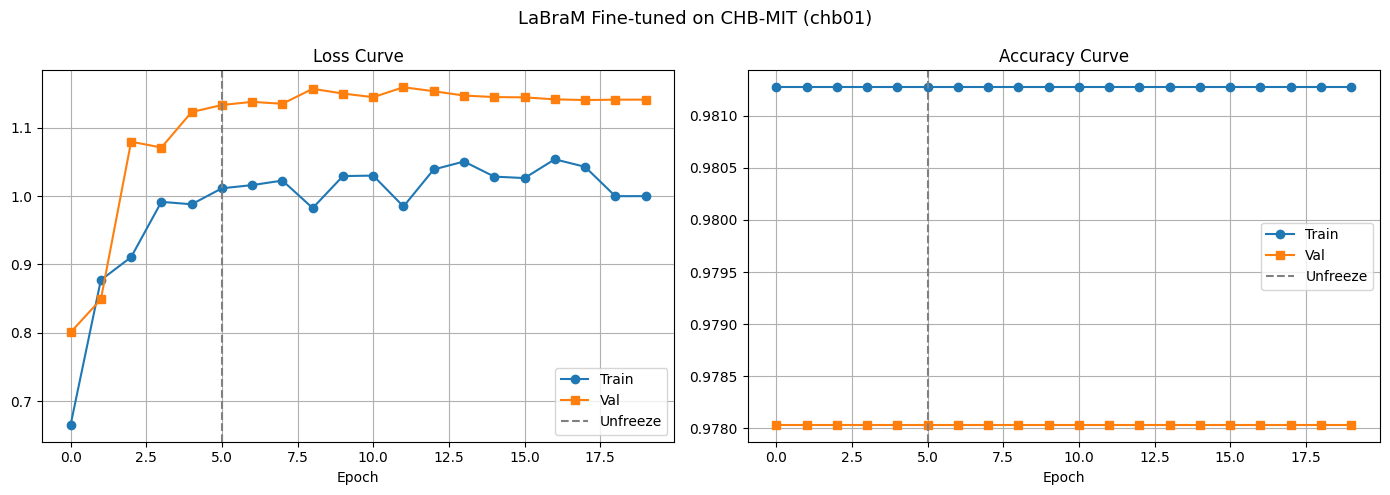

💾 Saved → labram_chbmit_final.pt
📈 Saved → labram_chbmit_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(
    axes,
    [("train_loss", "val_loss"), ("train_acc", "val_acc")],
    ["Loss Curve", "Accuracy Curve"]
):
    ax.plot(history[metric[0]], label="Train", marker='o')
    ax.plot(history[metric[1]], label="Val",   marker='s')
    ax.axvline(x=5, color='gray', linestyle='--', label='Unfreeze')
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True)

plt.suptitle("LaBraM Fine-tuned on CHB-MIT (chb01)", fontsize=13)
plt.tight_layout()
plt.savefig("labram_chbmit_curves.png", dpi=150)
plt.show()

torch.save({
    "model_state_dict" : model.state_dict(),
    "best_val_acc"     : best_val_acc,
    "history"          : history,
    "config"           : {
        "n_times"   : 800,
        "n_chans"   : 23,
        "n_outputs" : 2,
        "sfreq"     : 200,
        "window_sec": 4
    }
}, "labram_chbmit_final.pt")

print("💾 Saved → labram_chbmit_final.pt")
print("📈 Saved → labram_chbmit_curves.png")